In [1]:
#importing libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score,precision_score,confusion_matrix,f1_score,classification_report,roc_curve,roc_auc_score
import joblib

In [2]:
#loading dataset
df= pd.read_csv('netflix_customer_churn.csv')
df

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi


In [3]:
#overviewing data
df.shape


(5000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [5]:
df.head(4)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror


In [6]:
df.tail(5)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi
4999,82aeef39-ddb0-40ad-bae1-5c436e0cf042,57,Male,Basic,1.62,17,Africa,Mobile,8.99,1,Crypto,2,0.09,Action


In [7]:
#using describe it shows the numerical values in detail 
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [8]:
#viewing data types
df.dtypes


customer_id                object
age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
churned                     int64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object

In [9]:
# checking null values (not found in this dataset)
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [10]:
#checking for duplicate values 
df[df.duplicated]

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre


In [11]:
# viewing columns
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')

In [12]:
#seperating categories and numerical values
num_cols= df.select_dtypes(exclude =['object','bool'])
 

In [13]:
cat_cols=df.select_dtypes(include=['object','bool'])
cat_cols

,customer_id,gender,subscription_type,region,device,payment_method,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,Other,Basic,Africa,TV,Gift Card,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,Other,Standard,Europe,Mobile,Gift Card,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,Female,Standard,Asia,TV,Crypto,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,Other,Premium,Oceania,TV,Crypto,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,Other,Standard,Africa,Mobile,Crypto,Action
...,...,...,...,...,...,...,...
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,Female,Basic,Europe,Desktop,Credit Card,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,Female,Basic,North America,Desktop,PayPal,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,Male,Standard,South America,Desktop,Debit Card,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,Female,Basic,Europe,Laptop,Credit Card,Sci-Fi


In [14]:
df.drop(columns='customer_id',inplace=True) # removing customer id because it no longer contribute in finding churn

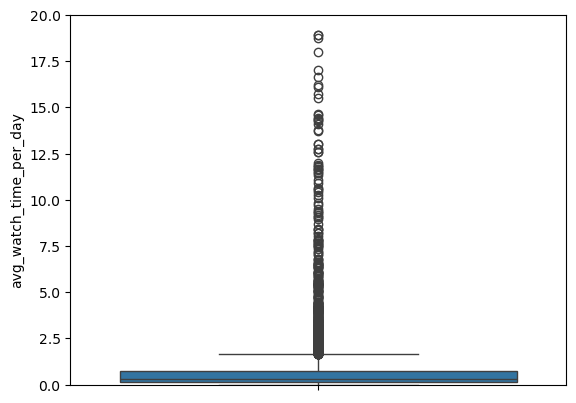

In [15]:
sns.boxplot(y=df['avg_watch_time_per_day'])
plt.ylim(0,20)
plt.show()

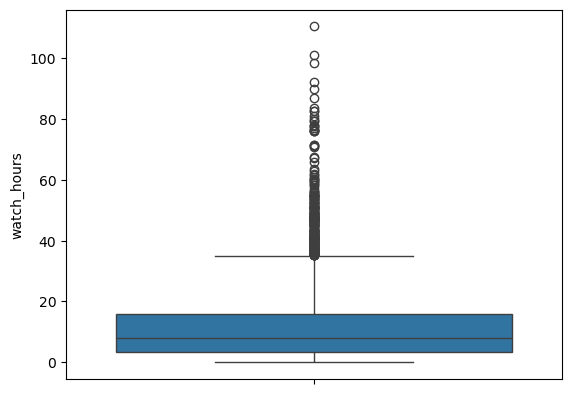

In [16]:
sns.boxplot(y=df['watch_hours'])
plt.show()

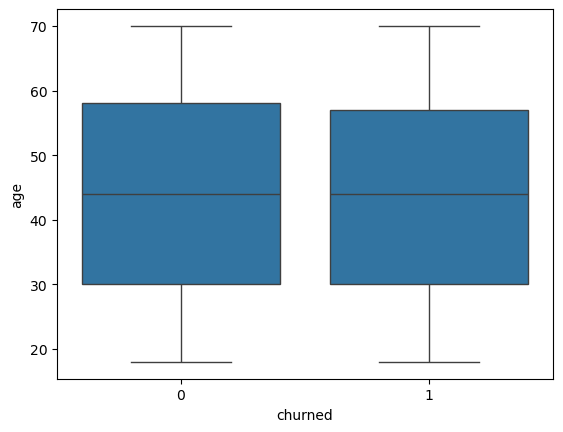

In [17]:
# visualising the variable (univariate)
sns.boxplot(x='churned',y='age',data=df,)
plt.show()

<Axes: xlabel='watch_hours', ylabel='Count'>

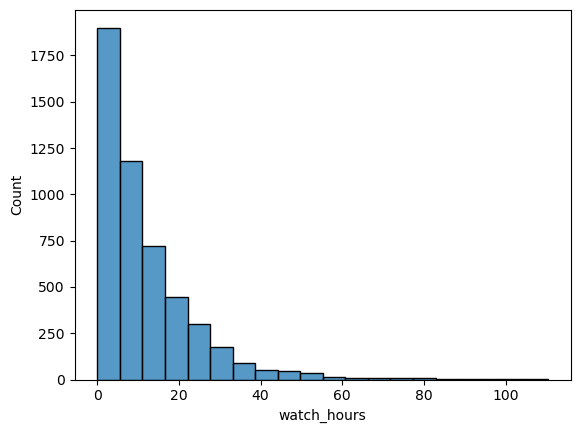

In [18]:
sns.histplot(df['watch_hours'],bins=20)

In [19]:
# bivariate analysis
pd.crosstab(df['subscription_type'],df['churned'])

churned,0,1
subscription_type,,
Basic,634,1027
Premium,953,740
Standard,898,748


In [20]:
pd.crosstab(df['subscription_type'],df['monthly_fee'])

monthly_fee,8.99,13.99,17.99
subscription_type,,,
Basic,1661,0,0
Premium,0,0,1693
Standard,0,1646,0


In [21]:
pd.crosstab(df['gender'],df['favorite_genre'])


favorite_genre,Action,Comedy,Documentary,Drama,Horror,Romance,Sci-Fi
gender,,,,,,,
Female,246,239,242,229,235,249,271
Male,234,211,244,265,244,224,232
Other,217,235,243,237,234,252,217


In [22]:

pd.crosstab(df['monthly_fee'],df['churned'])


churned,0,1
monthly_fee,,
8.99,634,1027
13.99,898,748
17.99,953,740


In [23]:
corr=df.corr(numeric_only=True)

Text(0.5, 1.0, 'Heatmap')

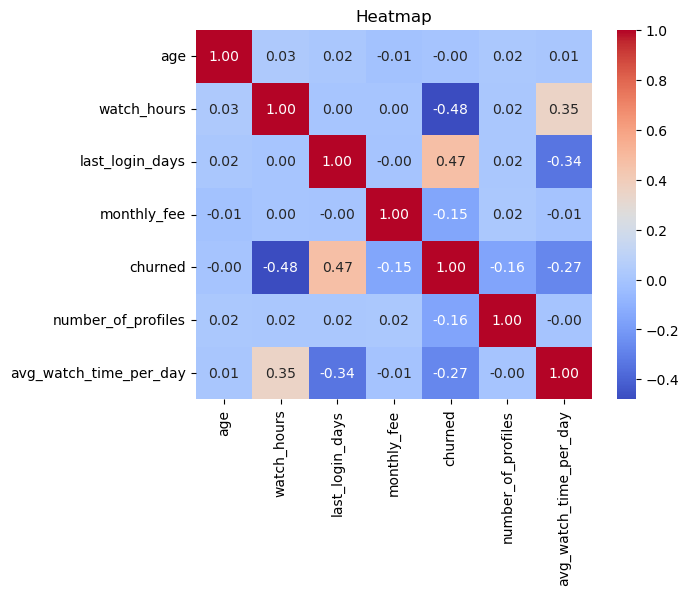

In [24]:
sns.heatmap(corr,cmap='coolwarm',cbar=True,fmt='.2f',annot=True)
plt.title('Heatmap')

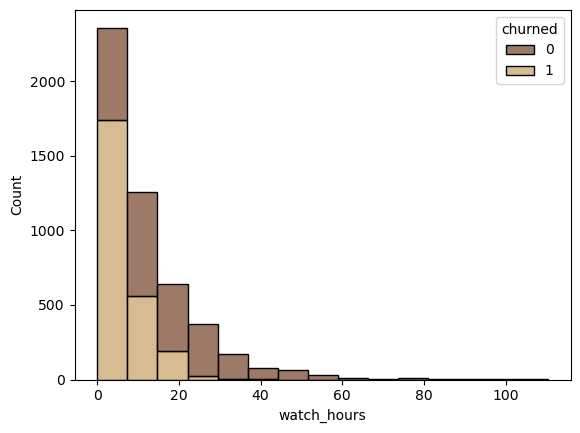

In [25]:
sns.histplot(data=df, x='watch_hours',hue='churned',bins=15,multiple='stack',palette=['#7b4e34','#c9a66b'])
plt.show()


In [26]:
#from heat map its is noted that churned has negative corelation with watch hours and churned has postive corelation with last_login days

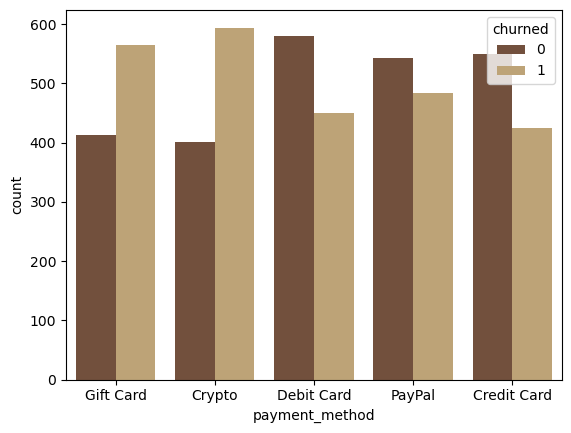

In [27]:
sns.countplot(x='payment_method',hue='churned' ,data=df,palette=['#7b4e34','#c9a66b'])
plt.show()

In [28]:
df.head(5)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [29]:
# columns choosen age,subscription_type,gender,watchhours,last_login,monthly fee,payment_method	number_of_profiles	avg_watch_time_per_day	

In [30]:
bins = [0,18,25,35,45,55,100]
labels=['<18','18-25','26-34','35-44','45-54','55+']
df['age_group']=pd.cut(df['age'],bins=bins,labels=labels)

In [31]:
#genres and age group 
pd.crosstab(df['favorite_genre'],df['age_group'])

age_group,<18,18-25,26-34,35-44,45-54,55+
favorite_genre,,,,,,
Action,18,89,143,113,145,189
Comedy,8,91,132,122,122,210
Documentary,13,111,105,154,148,198
Drama,16,97,156,138,115,209
Horror,18,85,144,125,142,199
Romance,17,105,127,120,121,235
Sci-Fi,18,115,142,108,126,211


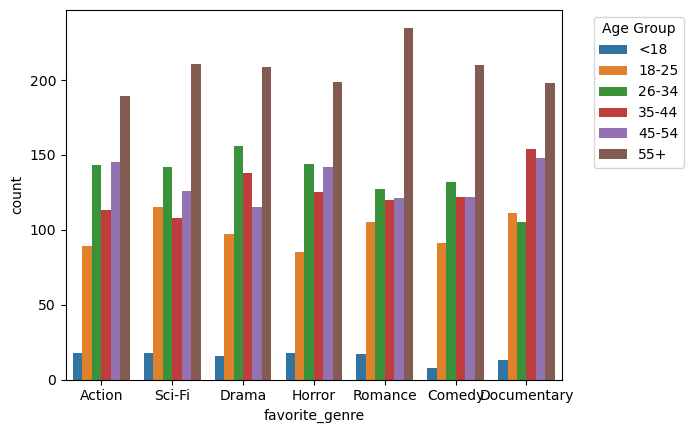

In [32]:
sns.countplot(x='favorite_genre',hue='age_group',data=df )
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

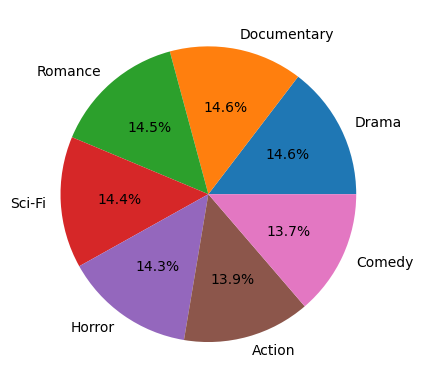

In [33]:
genre=df['favorite_genre'].value_counts()
plt.pie(genre,labels=genre.index,autopct='%1.1f%%')
plt.show()

C:\Users\dowfi\AppData\Local\Temp\ipykernel_9380\1306535410.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='churned',y='last_login_days',data=df,errorbar=None, palette=['#7b4e34','#c9a66b'])


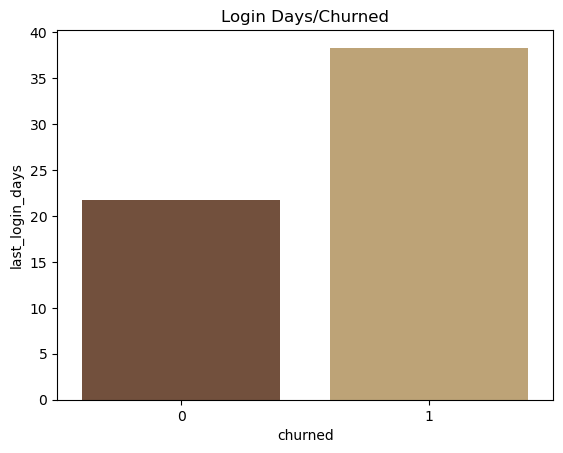

In [34]:
sns.barplot(x='churned',y='last_login_days',data=df,errorbar=None, palette=['#7b4e34','#c9a66b'])
plt.title('Login Days/Churned')
plt.show()

In [35]:

countplot(x='subscription_type',hue='churned',data=df)

NameError: name 'countplot' is not defined

In [ ]:
bins = [0,2,4,6,8,10,12,20,40,60,100]
labels = ['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-20', '20-40', '40-60', '60-100']


df['watchgrp']=pd.cut(df['watch_hours'],bins=bins,labels=labels)
sns.countplot( x='watchgrp',hue='device',data=df)

<Axes: xlabel='churned', ylabel='last_login_days'>

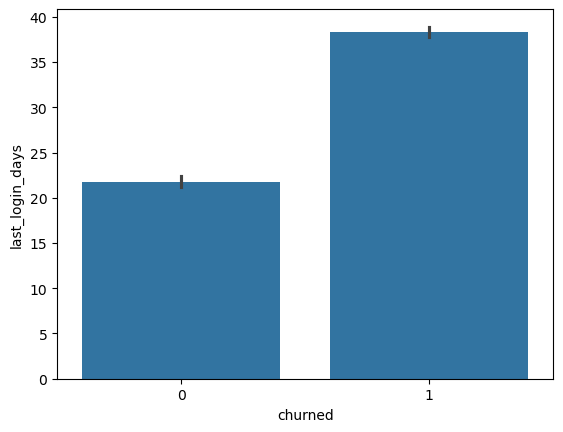

In [36]:
sns.barplot(x='churned',y='last_login_days',data=df)

In [37]:
cat_cols.drop(columns=['region','device','favorite_genre','customer_id'],inplace=True)


In [38]:
num_cols.drop(columns=['avg_watch_time_per_day'],inplace=True)

In [39]:
df['age_group']=pd.cut(df['age'],bins=[0,18,25,35,50,100],labels=['<18','18-24','25-34','35-49','50+'])

In [40]:
#encoding 
cat_code= pd.get_dummies(cat_cols,drop_first=True).astype(int)

In [41]:
cat_cols

,gender,subscription_type,payment_method
0,Other,Basic,Gift Card
1,Other,Standard,Gift Card
2,Female,Standard,Crypto
3,Other,Premium,Crypto
4,Other,Standard,Crypto
...,...,...,...
4995,Female,Basic,Credit Card
4996,Female,Basic,PayPal
4997,Male,Standard,Debit Card
4998,Female,Basic,Credit Card


In [42]:
Not_churn = num_cols.drop(columns='churned')

In [43]:
scaler = StandardScaler()
numcols=Not_churn.columns
scaled=scaler.fit_transform(Not_churn)
num_scaled = pd.DataFrame(scaled,columns=numcols,index=Not_churn.index)

In [44]:
f_df=pd.concat([num_scaled,cat_code] ,axis=1)
f_df

,age,watch_hours,last_login_days,monthly_fee,number_of_profiles,gender_Male,gender_Other,subscription_type_Premium,subscription_type_Standard,payment_method_Crypto,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal
0,0.461471,0.256425,-0.062152,-1.271341,-1.429965,0,1,0,0,0,0,1,0
1,0.203399,-0.911432,-0.632462,0.083051,1.395494,0,1,0,1,0,0,1,0
2,-1.086959,0.388777,-1.145741,0.083051,-0.723600,0,0,0,1,1,0,0,0
3,0.590506,-0.594288,-1.031679,1.166565,-0.723600,0,1,1,0,1,0,0,0
4,0.784060,-0.812377,-0.974648,0.083051,-0.723600,0,1,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.603102,3.123211,-1.088710,-1.271341,0.689129,0,0,0,0,0,0,0,0
4996,1.493757,-0.200563,-1.601989,-1.271341,-0.017235,0,0,0,0,0,0,0,1
4997,1.429239,0.407922,1.078468,0.083051,-0.723600,1,0,0,1,0,1,0,0
4998,0.977614,-0.210551,-1.544958,-1.271341,0.689129,0,0,0,0,0,0,0,0


In [45]:
num_cols

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles
0,51,14.73,29,8.99,1,1
1,47,0.70,19,13.99,1,5
2,27,16.32,10,13.99,0,2
3,53,4.51,12,17.99,1,2
4,56,1.89,13,13.99,1,2
...,...,...,...,...,...,...
4995,19,49.17,11,8.99,0,4
4996,67,9.24,2,8.99,0,3
4997,66,16.55,49,13.99,1,2
4998,59,9.12,3,8.99,0,4


In [46]:
#modelling 
X=f_df
y=df['churned']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)
Log = LogisticRegression()
Log.fit(X_train,y_train)
pred=Log.predict(X_test)
print('The accuracy score for the model is :',accuracy_score(y_test,pred))
print('The recall score for the model is :',recall_score(y_test,pred))
print('The precision score for the model is :',precision_score(y_test,pred))
print('The f1 score for the model is :',f1_score(y_test,pred))
print('The confusion matrix for the model is :',confusion_matrix(y_test,pred))
print('The classification report for the model is :',classification_report(y_test,pred))

The accuracy score for the model is : 0.8793333333333333
The recall score for the model is : 0.8943298969072165
The precision score for the model is : 0.8751576292559899
The f1 score for the model is : 0.8846398980242193
The confusion matrix for the model is : [[625  99]
 [ 82 694]]
The classification report for the model is :               precision    recall  f1-score   support

           0       0.88      0.86      0.87       724
           1       0.88      0.89      0.88       776

    accuracy                           0.88      1500
   macro avg       0.88      0.88      0.88      1500
weighted avg       0.88      0.88      0.88      1500



In [47]:
features = X_train.columns
coeff = Log.coef_[0]

fimport = pd.DataFrame({
    'features':features,
    'coefficient':coeff,
    'odds':np.exp(coeff)
}).sort_values(by='coefficient',ascending=False,key=abs)
fimport

,features,coefficient,odds
1,watch_hours,-4.537490,0.010700
2,last_login_days,2.787349,16.237915
11,payment_method_Gift Card,1.457822,4.296591
9,payment_method_Crypto,1.362180,3.904695
4,number_of_profiles,-1.040362,0.353327
8,subscription_type_Standard,-0.942161,0.389784
3,monthly_fee,-0.846036,0.429113
10,payment_method_Debit Card,-0.373473,0.688339
5,gender_Male,-0.325784,0.721961
6,gender_Other,-0.308184,0.734780


In [48]:
df['churned'].value_counts(normalize=True)

churned
1    0.503
0    0.497
Name: proportion, dtype: float64

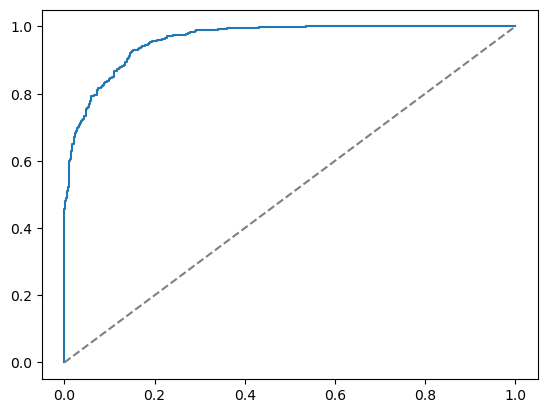

In [49]:
y_probs=Log.predict_proba(X_test)[:,1]
fpr,tpr,threshold=roc_curve(y_test,y_probs)

plt.plot(fpr,tpr,label='Roc curve')
plt.plot([0,1],[0,1],'--',color='Gray')

In [50]:
print(roc_auc_score(y_test,y_probs))

0.9602633564959846


In [51]:
joblib.dump(Log,'Churn analysis.pkl')

['Churn analysis.pkl']

In [52]:
DT_pipeline = Pipeline(steps=[('model',DecisionTreeClassifier(max_depth=5))])
DT_pipeline.fit(X_train,y_train)
dt_ypred=DT_pipeline.predict(X_test)

print('accuracy',DT_pipeline.score(X_test,y_test))

accuracy 0.9273333333333333


In [53]:
 print('The accuracy score for the model is :',accuracy_score(y_test,dt_ypred))
print('The recall score for the model is :',recall_score(y_test,dt_ypred))
print('The precision score for the model is :',precision_score(y_test,dt_ypred))
print('The f1 score for the model is :',f1_score(y_test,dt_ypred))
print('The confusion matrix for the model is :',confusion_matrix(y_test,dt_ypred))
print('The classification report for the model is :',classification_report(y_test,dt_ypred))

The accuracy score for the model is : 0.9273333333333333
The recall score for the model is : 0.8724226804123711
The precision score for the model is : 0.9854439592430859
The f1 score for the model is : 0.9254955570745045
The confusion matrix for the model is : [[714  10]
 [ 99 677]]
The classification report for the model is :               precision    recall  f1-score   support

           0       0.88      0.99      0.93       724
           1       0.99      0.87      0.93       776

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



In [54]:
joblib.dump(DT_pipeline,'DT.pkl')

['DT.pkl']

In [55]:
rt_pipeline = Pipeline(steps=[('model',RandomForestClassifier( n_estimators=200, 
        max_depth=None, 
        random_state=42))])
rt_pipeline.fit(X_train,y_train)
rt_y = rt_pipeline.predict(X_test)
print('accuracy',rt_pipeline.score(X_test,y_test))

accuracy 0.97


In [56]:
print("Train Accuracy:", rt_pipeline.score(X_train, y_train))
print("Test Accuracy:", rt_pipeline.score(X_test, y_test))


Train Accuracy: 1.0
Test Accuracy: 0.97


In [57]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test, rt_y))
print("\nClassification Report:\n", classification_report(y_test, rt_y))


Confusion Matrix:
 [[708  16]
 [ 29 747]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       724
           1       0.98      0.96      0.97       776

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500



In [58]:
 print('The accuracy score for the model is :',accuracy_score(y_test,rt_y))
print('The recall score for the model is :',recall_score(y_test,rt_y))
print('The precision score for the model is :',precision_score(y_test,rt_y))
print('The f1 score for the model is :',f1_score(y_test,rt_y))
print('The confusion matrix for the model is :',confusion_matrix(y_test,rt_y))
print('The classification report for the model is :',classification_report(y_test,rt_y))

The accuracy score for the model is : 0.97
The recall score for the model is : 0.9626288659793815
The precision score for the model is : 0.9790301441677588
The f1 score for the model is : 0.9707602339181286
The confusion matrix for the model is : [[708  16]
 [ 29 747]]
The classification report for the model is :               precision    recall  f1-score   support

           0       0.96      0.98      0.97       724
           1       0.98      0.96      0.97       776

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500



In [59]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rt_pipeline, X_train, y_train, cv=5, scoring="accuracy")
print("Cross-validation Accuracy:", scores.mean())


Cross-validation Accuracy: 0.9791428571428572


In [60]:
joblib.dump(rt_pipeline,'rt.pkl')

['rt.pkl']

<Figure size 3000x1200 with 0 Axes>

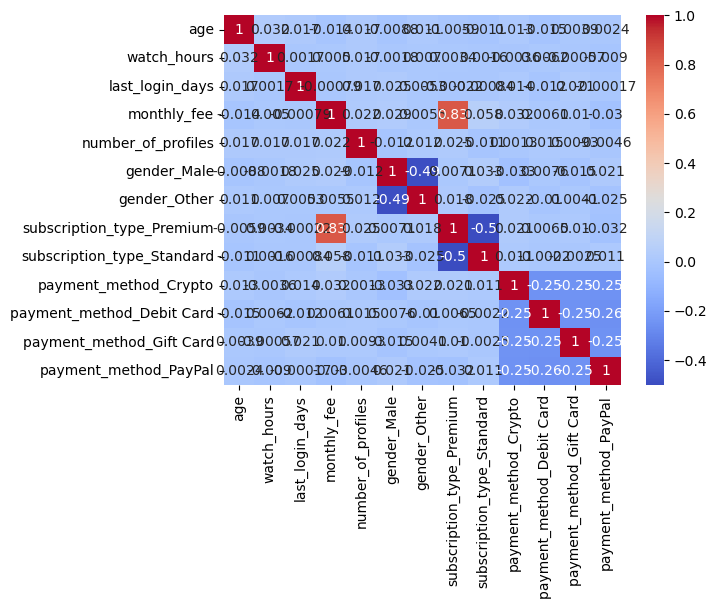

<Figure size 3000x1200 with 0 Axes>

In [61]:
corr = f_df.corr()
sns.heatmap(corr,cmap='coolwarm',annot=True)
plt.figure(figsize=(30,12))